In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned stock market dataset
DATA_PATH = Path("../data/stock_market_cleaned.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (499, 8)


,Date,Open,High,Low,Close,Volume,Price_Change,Daily_Return_Pct
0,2024-01-01,101.77,102.19,99.38,100.85,330701.00,NaN,NaN
1,2024-01-02,102.65,102.95,100.50,100.74,289687.00,-0.11,-0.11
2,2024-01-03,100.41,103.12,100.18,101.81,440634.00,1.07,1.06
3,2024-01-04,104.76,106.20,104.07,104.19,235683.00,2.38,2.34
4,2024-01-05,103.29,104.10,101.37,103.94,368182.00,-0.25,-0.24


In [3]:
# Dataset structure
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              499 non-null    datetime64[ns]
 1   Open              499 non-null    float64       
 2   High              499 non-null    float64       
 3   Low               499 non-null    float64       
 4   Close             499 non-null    float64       
 5   Volume            499 non-null    float64       
 6   Price_Change      498 non-null    float64       
 7   Daily_Return_Pct  498 non-null    float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 31.3 KB

Column Names:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Price_Change', 'Daily_Return_Pct']

Missing Values:
Date                0
Open                0
High                0
Low                 0
Close               0
Volume              0
Price_Change        1
Da

## 4. Descriptive Statistical Analysis

This section summarizes the central tendency, variability, and distribution of the financial variables using descriptive statistics.

In [4]:
# Descriptive statistics for financial variables

numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Price_Change",
    "Daily_Return_Pct"
]

descriptive_stats = df[numeric_columns].describe().T

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
Open,499.00,123.09,23.70,87.43,98.84,122.43,146.51,167.92
High,499.00,124.51,23.65,88.73,100.24,123.93,147.67,169.33
Low,499.00,121.61,23.68,85.50,97.13,121.12,145.12,166.23
Close,499.00,123.05,23.62,87.28,98.69,122.30,145.93,166.35
Volume,499.00,250946.04,138087.40,10138.00,143122.50,241312.00,363379.50,497505.00
Price_Change,498.00,0.11,1.47,-4.76,-0.95,0.12,1.07,5.88
Daily_Return_Pct,498.00,0.09,1.24,-3.89,-0.74,0.10,0.85,5.25


In [5]:
# Date range
print("Start Date:", df["Date"].min().date())
print("End Date:", df["Date"].max().date())

# Closing price statistics
print("\nClosing Price Analysis")
print("Mean:", round(df["Close"].mean(), 2))
print("Median:", round(df["Close"].median(), 2))
print("Minimum:", round(df["Close"].min(), 2))
print("Maximum:", round(df["Close"].max(), 2))
print("Standard Deviation:", round(df["Close"].std(), 2))

# Daily return statistics
print("\nDaily Return Analysis")
print("Average Daily Return (%):", round(df["Daily_Return_Pct"].mean(), 4))
print("Median Daily Return (%):", round(df["Daily_Return_Pct"].median(), 4))
print("Minimum Daily Return (%):", round(df["Daily_Return_Pct"].min(), 4))
print("Maximum Daily Return (%):", round(df["Daily_Return_Pct"].max(), 4))

Start Date: 2024-01-01
End Date: 2025-11-28

Closing Price Analysis
Mean: 123.05
Median: 122.3
Minimum: 87.28
Maximum: 166.35
Standard Deviation: 23.62

Daily Return Analysis
Average Daily Return (%): 0.0942
Median Daily Return (%): 0.0982
Minimum Daily Return (%): -3.8923
Maximum Daily Return (%): 5.2458


## 5. Correlation Analysis

Correlation analysis is used to measure the strength and direction of linear relationships between numerical financial variables. The Pearson correlation coefficient ranges from -1 to +1.

In [6]:
# Select financial variables for correlation analysis

correlation_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Price_Change",
    "Daily_Return_Pct"
]

# Calculate Pearson correlation matrix
correlation_matrix = df[correlation_columns].corr()

correlation_matrix.round(2)

,Open,High,Low,Close,Volume,Price_Change,Daily_Return_Pct
Open,1.00,1.00,1.00,1.00,-0.05,0.04,0.03
High,1.00,1.00,1.00,1.00,-0.05,0.05,0.04
Low,1.00,1.00,1.00,1.00,-0.05,0.05,0.04
Close,1.00,1.00,1.00,1.00,-0.05,0.05,0.04
Volume,-0.05,-0.05,-0.05,-0.05,1.00,0.05,0.05
Price_Change,0.04,0.05,0.05,0.05,0.05,1.00,0.98
Daily_Return_Pct,0.03,0.04,0.04,0.04,0.05,0.98,1.00


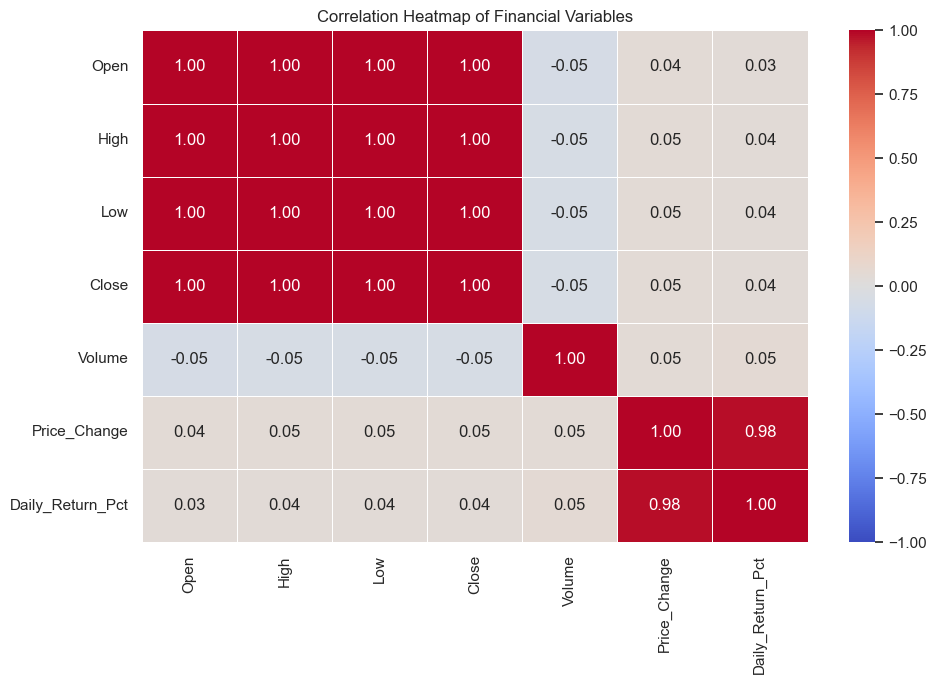

In [7]:
# Visualize the correlation matrix

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap of Financial Variables")
plt.tight_layout()
plt.show()

## 6. Financial Data Visualization

### 6.1 Closing Price Trend

A line chart is used to visualize changes in the stock's closing price over time. The date is plotted on the x-axis, while the closing price is plotted on the y-axis.

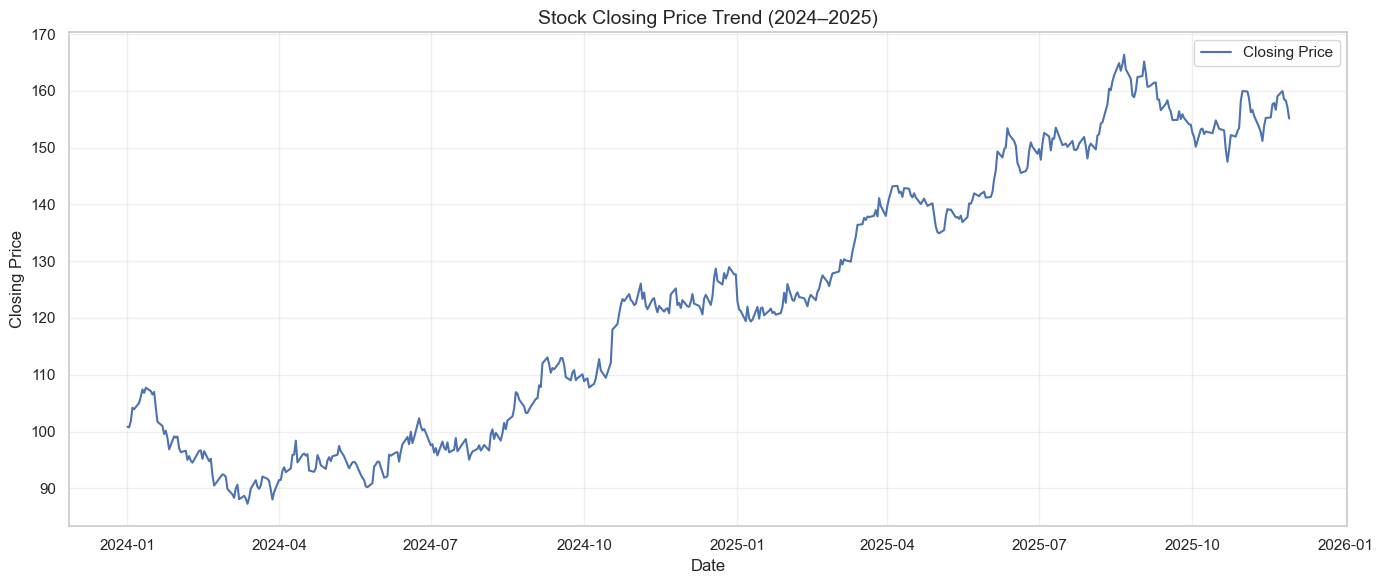

In [8]:
# Closing Price Trend Over Time

plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Close"],
    label="Closing Price",
    linewidth=1.5
)

plt.title("Stock Closing Price Trend (2024–2025)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# Save the closing price chart

chart_path = Path("../visualizations/closing_price_trend.png")

plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], linewidth=1.5)

plt.title("Stock Closing Price Trend (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.close()

print("Chart saved to:", chart_path.resolve())

Chart saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\closing_price_trend.png


### 6.2 Histogram of Closing Prices

A histogram shows the frequency distribution of closing prices by grouping values into intervals called bins. It helps identify the concentration, spread, and shape of the price distribution.

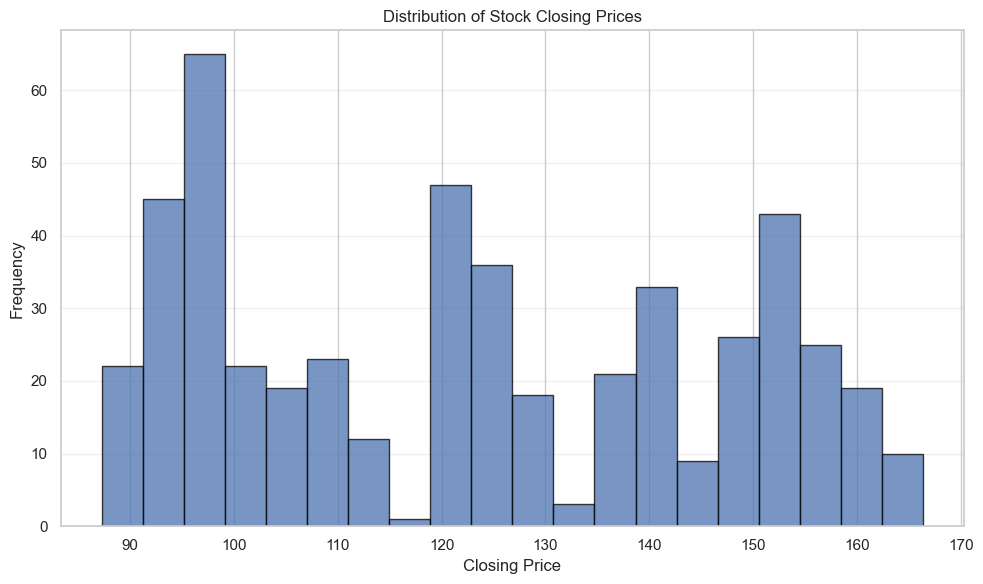

In [10]:
# Histogram of Closing Prices

plt.figure(figsize=(10, 6))

plt.hist(
    df["Close"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.title("Distribution of Stock Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Save the closing price histogram

histogram_path = Path("../visualizations/closing_price_histogram.png")

plt.figure(figsize=(10, 6))

plt.hist(
    df["Close"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.title("Distribution of Stock Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(histogram_path, dpi=300, bbox_inches="tight")
plt.close()

print("Histogram saved to:", histogram_path.resolve())

Histogram saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\closing_price_histogram.png


### 6.3 Histogram of Daily Returns

This histogram shows the distribution of daily percentage returns. It helps examine the spread of returns, their concentration around zero, and the presence of unusually large positive or negative daily movements.

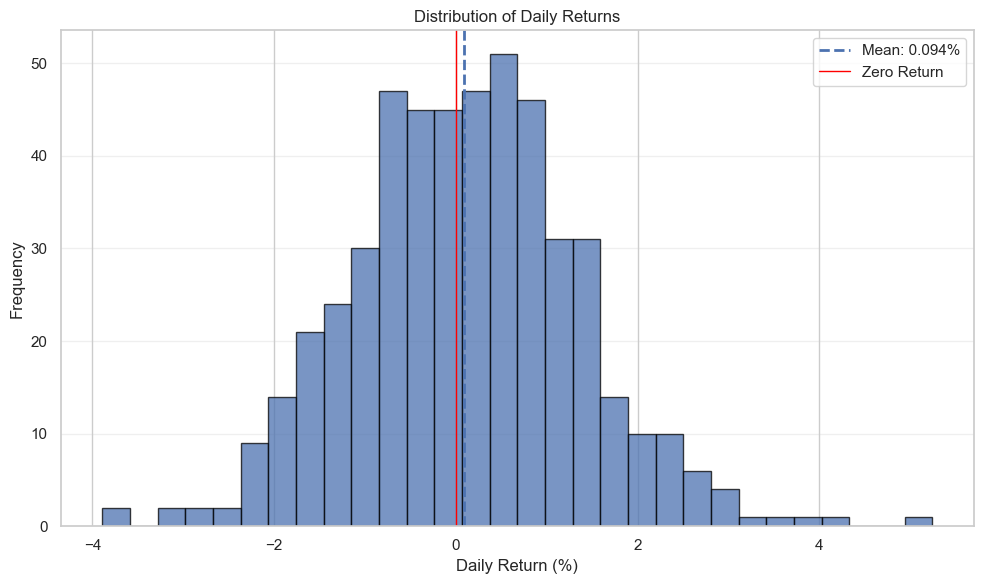

In [12]:
# Histogram of Daily Returns

returns = df["Daily_Return_Pct"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    returns,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    returns.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean: {returns.mean():.3f}%"
)

plt.axvline(
    0,
    color="red",
    linestyle="-",
    linewidth=1,
    label="Zero Return"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Save the daily returns histogram

returns_hist_path = Path("../visualizations/daily_returns_histogram.png")

plt.figure(figsize=(10, 6))

plt.hist(
    returns,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    returns.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean: {returns.mean():.3f}%"
)

plt.axvline(
    0,
    color="red",
    linestyle="-",
    linewidth=1,
    label="Zero Return"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(returns_hist_path, dpi=300, bbox_inches="tight")
plt.close()

print("Daily returns histogram saved to:", returns_hist_path.resolve())

Daily returns histogram saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\daily_returns_histogram.png


### 6.4 Scatter Plot: Trading Volume vs. Closing Price

A scatter plot is used to visualize the relationship between trading volume and closing price. Each point represents one trading day. The x-axis shows trading volume, and the y-axis shows the closing price.

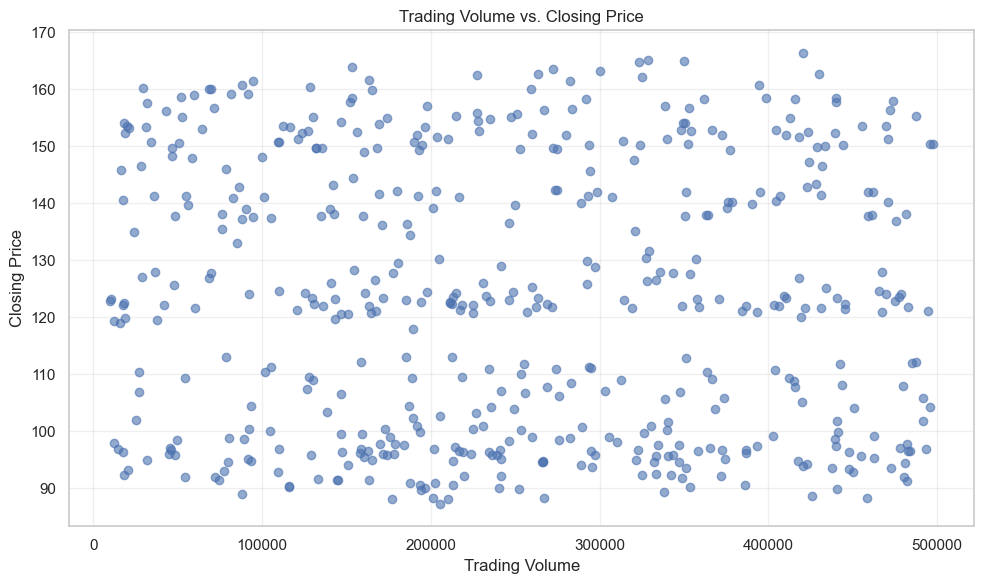

In [14]:
# Scatter Plot: Trading Volume vs. Closing Price

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Volume"],
    df["Close"],
    alpha=0.6
)

plt.title("Trading Volume vs. Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Save the scatter plot

scatter_path = Path("../visualizations/volume_vs_closing_price.png")

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Volume"],
    df["Close"],
    alpha=0.6
)

plt.title("Trading Volume vs. Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.close()

print("Scatter plot saved to:", scatter_path.resolve())

Scatter plot saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\volume_vs_closing_price.png


### 6.5 Box Plot: Closing Price and Daily Returns

A box plot summarizes the distribution of numerical data using the median, lower quartile, upper quartile, and whiskers. Points beyond the whiskers may be flagged as potential outliers under the 1.5 × IQR rule.

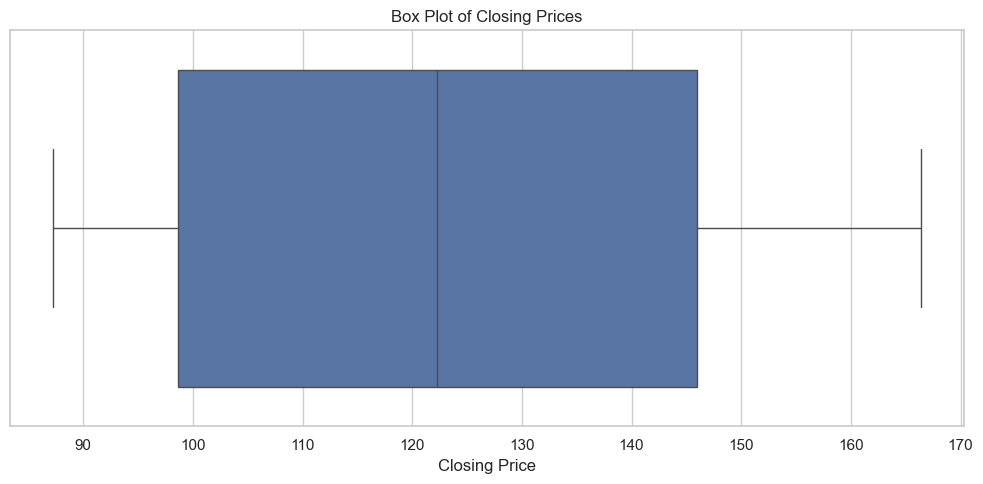

In [16]:
# Box Plot of Closing Prices

plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Close"])

plt.title("Box Plot of Closing Prices")
plt.xlabel("Closing Price")

plt.tight_layout()
plt.show()

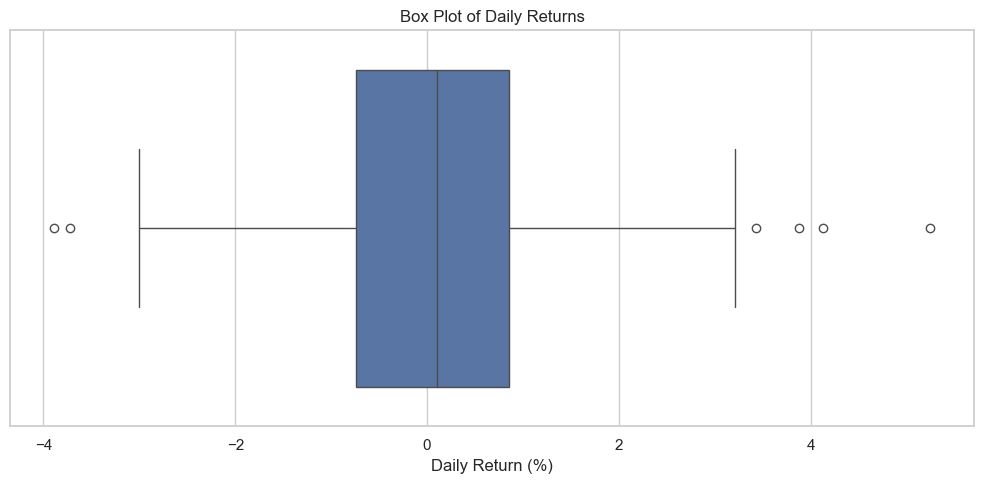

In [17]:
# Box Plot of Daily Returns

plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Daily_Return_Pct"].dropna())

plt.title("Box Plot of Daily Returns")
plt.xlabel("Daily Return (%)")

plt.tight_layout()
plt.show()

In [18]:
# Save Closing Price Box Plot

close_box_path = Path("../visualizations/closing_price_boxplot.png")

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Close"])
plt.title("Box Plot of Closing Prices")
plt.xlabel("Closing Price")
plt.tight_layout()

plt.savefig(close_box_path, dpi=300, bbox_inches="tight")
plt.close()


# Save Daily Returns Box Plot

returns_box_path = Path("../visualizations/daily_returns_boxplot.png")

plt.figure(figsize=(10, 5))
sns.boxplot(x=df["Daily_Return_Pct"].dropna())
plt.title("Box Plot of Daily Returns")
plt.xlabel("Daily Return (%)")
plt.tight_layout()

plt.savefig(returns_box_path, dpi=300, bbox_inches="tight")
plt.close()

print("Closing price box plot saved to:", close_box_path.resolve())
print("Daily returns box plot saved to:", returns_box_path.resolve())

Closing price box plot saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\closing_price_boxplot.png
Daily returns box plot saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\daily_returns_boxplot.png


### 6.6 Statistical Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in closing prices and daily returns. Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged as potential outliers.

In [19]:
# Function to detect potential outliers using IQR

def detect_outliers(series):
    series = series.dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Values": outliers.tolist()
    }


# Analyze closing prices
close_outliers = detect_outliers(df["Close"])

# Analyze daily returns
return_outliers = detect_outliers(df["Daily_Return_Pct"])

print("Closing Price Outlier Analysis:")
print(close_outliers)

print("\nDaily Return Outlier Analysis:")
print(return_outliers)

Closing Price Outlier Analysis:
{'Q1': np.float64(98.685), 'Q3': np.float64(145.93), 'IQR': np.float64(47.245000000000005), 'Lower_Bound': np.float64(27.817499999999995), 'Upper_Bound': np.float64(216.7975), 'Outlier_Count': 0, 'Outlier_Values': []}

Daily Return Outlier Analysis:
{'Q1': np.float64(-0.7394502463838187), 'Q3': np.float64(0.8504058611760679), 'IQR': np.float64(1.5898561075598865), 'Lower_Bound': np.float64(-3.1242344077236486), 'Upper_Bound': np.float64(3.235190022515898), 'Outlier_Count': 6, 'Outlier_Values': [-3.89227642276424, 4.123711340206193, 3.425972713491654, 3.8761127596439016, 5.245784637344997, -3.727778212859256]}


In [20]:
# Display outlier analysis in a readable format

for name, result in [
    ("Closing Price", close_outliers),
    ("Daily Returns", return_outliers)
]:
    print(f"\n{'=' * 40}")
    print(f"{name} Outlier Analysis")
    print(f"{'=' * 40}")

    print(f"Q1: {result['Q1']:.4f}")
    print(f"Q3: {result['Q3']:.4f}")
    print(f"IQR: {result['IQR']:.4f}")
    print(f"Lower Bound: {result['Lower_Bound']:.4f}")
    print(f"Upper Bound: {result['Upper_Bound']:.4f}")
    print(f"Outlier Count: {result['Outlier_Count']}")
    print(f"Outlier Values: {result['Outlier_Values']}")


Closing Price Outlier Analysis
Q1: 98.6850
Q3: 145.9300
IQR: 47.2450
Lower Bound: 27.8175
Upper Bound: 216.7975
Outlier Count: 0
Outlier Values: []

Daily Returns Outlier Analysis
Q1: -0.7395
Q3: 0.8504
IQR: 1.5899
Lower Bound: -3.1242
Upper Bound: 3.2352
Outlier Count: 6
Outlier Values: [-3.89227642276424, 4.123711340206193, 3.425972713491654, 3.8761127596439016, 5.245784637344997, -3.727778212859256]


### 6.7 Outlier Detection Results and Interpretation

The Interquartile Range (IQR) method was used to identify potential outliers in closing prices and daily returns.

**Closing Price Analysis:**
- Q1: 98.6850
- Q3: 145.9300
- IQR: 47.2450
- Lower Bound: 27.8175
- Upper Bound: 216.7975
- Potential Outliers: 0

No closing prices were identified as potential outliers under the 1.5 × IQR rule.

**Daily Returns Analysis:**
- Q1: -0.7395%
- Q3: 0.8504%
- IQR: 1.5899
- Lower Bound: -3.1242%
- Upper Bound: 3.2352%
- Potential Outliers: 6

Six daily returns were flagged as potential outliers. These observations represent unusually large positive or negative daily movements. They were retained because statistical outliers are not necessarily data errors.

The analysis is based on a simulated financial dataset and should not be interpreted as evidence about actual stock market behavior.

### 6.8 Histogram: Trading Volume Distribution

A histogram is used to visualize the distribution of trading volume across the dataset. The x-axis represents trading volume, while the y-axis shows the frequency of observations within each volume range.

This visualization helps identify the concentration, spread, and potential unusual values in trading volume.

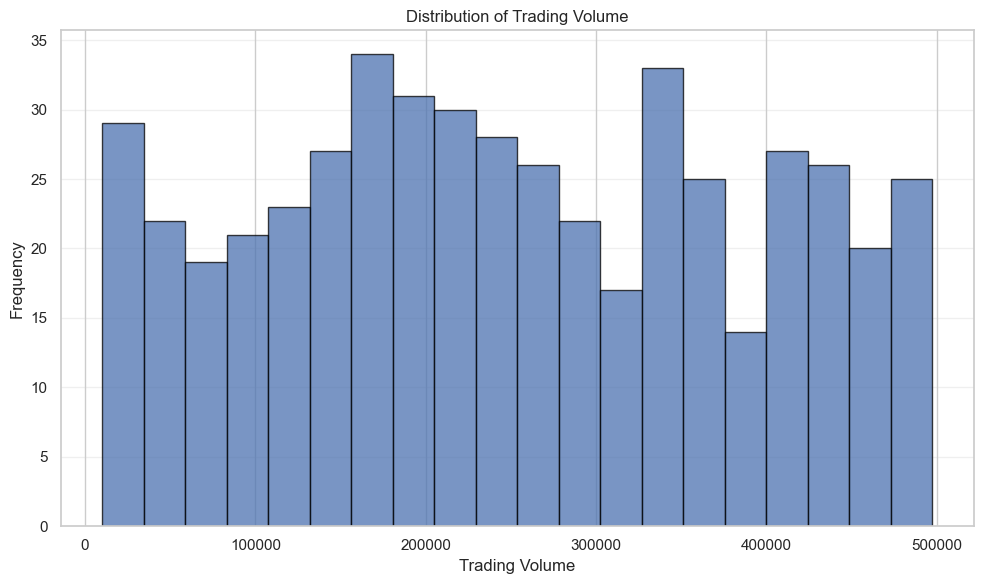

In [21]:
# Histogram: Trading Volume Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    df["Volume"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.title("Distribution of Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Save the trading volume histogram

volume_hist_path = Path("../visualizations/volume_distribution.png")

plt.figure(figsize=(10, 6))

plt.hist(
    df["Volume"],
    bins=20,
    edgecolor="black",
    alpha=0.75
)

plt.title("Distribution of Trading Volume")
plt.xlabel("Trading Volume")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(volume_hist_path, dpi=300, bbox_inches="tight")
plt.close()

print("Volume histogram saved to:", volume_hist_path.resolve())

Volume histogram saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\volume_distribution.png


### 6.9 Trading Volume Distribution: Interpretation

The trading volume histogram illustrates the distribution of daily trading volumes across the simulated financial dataset.

The observations are spread across a broad range of volume values, approximately from 1,000 to 50,000. Different volume intervals contain varying numbers of observations, with some intervals recording more than 30 observations and others fewer than 15.

The distribution does not show a single dominant concentration across the entire range. This visualization helps understand the variability in trading activity within the simulated dataset.

The histogram alone does not establish whether extreme volume values are statistical outliers. Further analysis would be required to identify potential outliers.

### 6.10 Line Chart: Daily Trading Volume Trend

A line chart is used to visualize daily trading volume over time. The x-axis represents the date, and the y-axis represents trading volume.

This visualization helps identify fluctuations in trading activity and periods with relatively high or low volume.

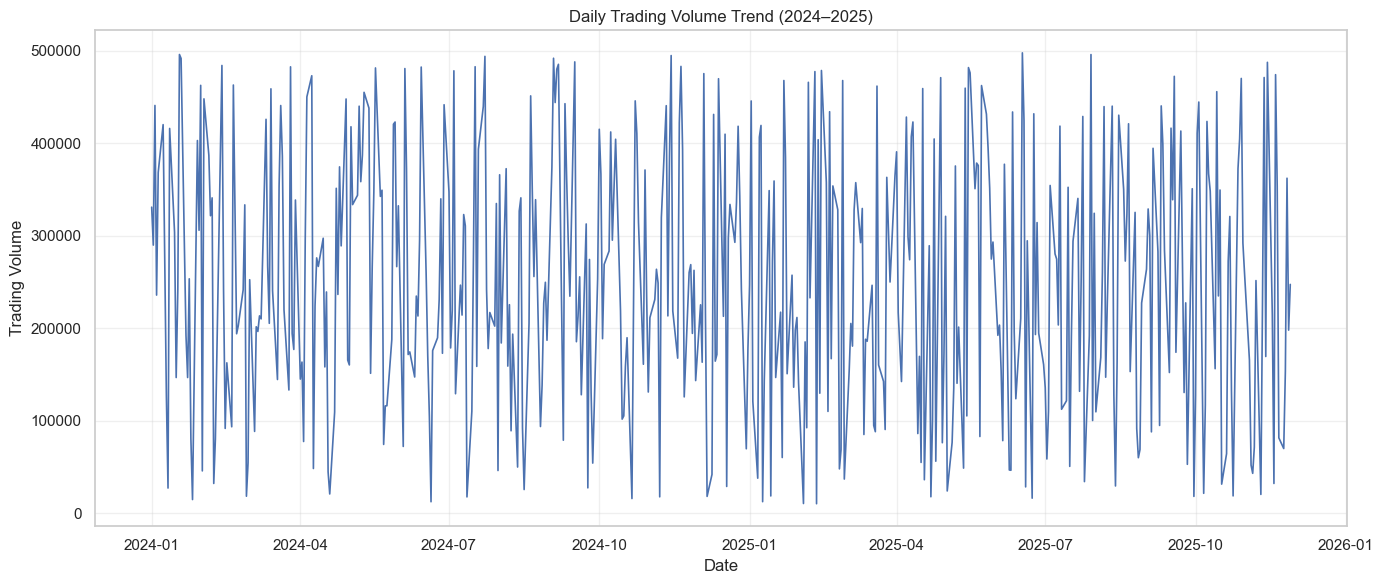

In [23]:
# Daily Trading Volume Trend

plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Volume"],
    linewidth=1.2
)

plt.title("Daily Trading Volume Trend (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Save the daily trading volume trend chart

volume_trend_path = Path("../visualizations/daily_volume_trend.png")

plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Volume"],
    linewidth=1.2
)

plt.title("Daily Trading Volume Trend (2024–2025)")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(volume_trend_path, dpi=300, bbox_inches="tight")
plt.close()

print("Volume trend chart saved to:", volume_trend_path.resolve())

Volume trend chart saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\visualizations\daily_volume_trend.png


### 6.11 Daily Trading Volume Trend: Interpretation

The daily trading volume line chart illustrates changes in trading activity from January 2024 to November 2025.

The simulated trading volume fluctuates considerably, ranging from relatively low values below 5,000 to high values approaching 50,000.

The chart shows frequent increases and decreases in daily volume, with no clear long-term upward or downward trend.

These fluctuations indicate variability in trading activity within the simulated dataset. However, the chart does not establish any causal relationship between trading volume and stock prices.

Since the dataset is simulated, these observations should not be interpreted as evidence of actual market behavior.

### 7. Final Statistical Summary

This section consolidates the descriptive statistics of closing prices, daily returns, and trading volume. It also reviews the correlation between numerical financial variables to summarize the main findings of the exploratory data analysis.

In [25]:
# Final Statistical Summary

summary_columns = ["Close", "Daily_Return_Pct", "Volume"]

final_summary = df[summary_columns].describe().round(4)

print("FINAL STATISTICAL SUMMARY")
display(final_summary)

FINAL STATISTICAL SUMMARY


,Close,Daily_Return_Pct,Volume
count,499.00,498.00,499.00
mean,123.05,0.09,250946.04
std,23.62,1.24,138087.40
min,87.28,-3.89,10138.00
25%,98.69,-0.74,143122.50
50%,122.30,0.10,241312.00
75%,145.93,0.85,363379.50
max,166.35,5.25,497505.00


In [26]:
# Correlation Summary

correlation_summary = df[
    ["Open", "High", "Low", "Close", "Volume", "Price_Change", "Daily_Return_Pct"]
].corr().round(3)

print("CORRELATION MATRIX")
display(correlation_summary)

CORRELATION MATRIX


,Open,High,Low,Close,Volume,Price_Change,Daily_Return_Pct
Open,1.00,1.00,1.00,1.00,-0.06,0.04,0.04
High,1.00,1.00,1.00,1.00,-0.05,0.05,0.04
Low,1.00,1.00,1.00,1.00,-0.05,0.05,0.04
Close,1.00,1.00,1.00,1.00,-0.05,0.05,0.04
Volume,-0.06,-0.05,-0.05,-0.05,1.00,0.05,0.05
Price_Change,0.04,0.05,0.05,0.05,0.05,1.00,0.98
Daily_Return_Pct,0.04,0.04,0.04,0.04,0.05,0.98,1.00


In [27]:
# Save final statistical summary and correlation matrix

summary_path = Path("../outputs/final_statistical_summary.csv")
correlation_path = Path("../outputs/final_correlation_matrix.csv")

final_summary.to_csv(summary_path)
correlation_summary.to_csv(correlation_path)

print("Statistical summary saved to:", summary_path.resolve())
print("Correlation matrix saved to:", correlation_path.resolve())

Statistical summary saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\outputs\final_statistical_summary.csv
Correlation matrix saved to: S:\Projects\Financial-Analytics-with-Python\Week_3\outputs\final_correlation_matrix.csv


## 8. Final EDA Findings and Conclusion

### 8.1 Descriptive Statistics

The final statistical summary shows that the average closing price is 123.0532, while the median closing price is 122.30.

The average daily return is approximately 0.0942%, with a standard deviation of approximately 1.228 percentage points.

The average trading volume is approximately 25,096.04, with a standard deviation of approximately 13,807.40, indicating substantial variation in trading activity.

### 8.2 Correlation Findings

The correlation matrix shows very strong positive correlations among Open, High, Low, and Close prices, with coefficients close to 0.999.

The correlation between trading volume and closing price is approximately -0.052, indicating a negligible linear relationship in this dataset.

### 8.3 Outlier Findings

The IQR method identified no potential outliers in closing prices and flagged six potential outliers in daily returns.

These observations were retained because statistical outliers are not necessarily data errors.

### 8.4 Conclusion

Exploratory Data Analysis was performed on 499 observations from a simulated financial dataset covering January 2024 to November 2025.

The analysis included descriptive statistics, correlation analysis, line charts, histograms, scatter plots, box plots, and IQR-based outlier detection.

The visualizations revealed fluctuations in closing prices and trading volume, while the statistical analysis highlighted relationships among financial variables.

Since the dataset is simulated, the findings should not be interpreted as evidence of actual stock market behavior.